# Calibration du Modèle d'Heston par Filtre Particulaire Auxiliaire (APF)


**Projet 2 : Calibration Modèle d'Heston par APF**

---

## Présentation du modèle

On considère le modèle d'Heston à temps continu :

$$
\begin{cases}
dS_s = S_s\left(r\,ds + \sqrt{v_s}\,dW^1_s\right) \\
dv_s = \lambda(\bar{v} - v_s)\,ds + \eta\sqrt{v_s}\,dW^2_s \\
dW^1_s \cdot dW^2_s = \rho\,ds
\end{cases}
$$

La discrétisation par schéma d'Euler modifié donne le système d'état-observation :

$$
\begin{cases}
y_t = C(\theta, v_t, S_t, K, \tau) + \sigma_\varepsilon\,\varepsilon_t \\
S_t = S_{t-1}\left(1 + r\Delta + \sqrt{\Delta\,v_t}\,Z^1_t\right) \\
v_t = \left|v_{t-1} + \lambda\Delta(\bar{v} - v_{t-1}) + \eta\sqrt{v_{t-1}\,\Delta}\,Z^2_t\right|
\end{cases}
$$

avec $(Z^1_t, Z^2_t) \sim \mathcal{N}(0, \Sigma_\rho)$ où $\Sigma_\rho = \begin{pmatrix}1 & \rho \\ \rho & 1\end{pmatrix}$, et $(\varepsilon_t)$ des bruits de mesure gaussiens i.i.d. de variance $\sigma^2_\varepsilon$.

**Remarque sur $\tau$ :** Conformément à l'énoncé, $\tau$ désigne la maturité d'un Call "rolling" observé chaque jour à maturité **constante**. La maturité ne décroît donc pas au fil du temps.

**Paramètres :**
- $\theta = (\lambda, \eta, \bar{v}, \rho) = (4,\; 0.4,\; 0.03,\; -0.5)$
- $\sigma^2_\varepsilon = 0.1$, $\tau = 1$, $r = 0.05$, $K = 100$

## 1. Importation des bibliothèques

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.laguerre import laggauss
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 120
})

## 2. Paramètres du modèle

In [45]:
# Paramètres structurels
lambda_    = 4.0      # Vitesse de retour à la moyenne
eta        = 0.4      # Volatilité de la variance
v_bar      = 0.03     # Niveau de variance à long terme
rho        = -0.5     # Corrélation entre les deux browniens
r          = 0.05     # Taux sans risque
K          = 100.0    # Strike
tau        = 1.0      # Maturité constante (en années)
sigma2_eps = 0.1      # Variance du bruit de mesure
sigma_eps  = np.sqrt(sigma2_eps)

# Discrétisation
n  = 252              # Nombre de pas (jours de trading)
dt = tau / n          # Pas de temps

print(f"Pas de discrétisation Delta = {dt:.6f}")
print(f"Condition de Feller : 2*lambda*v_bar = {2*lambda_*v_bar:.4f}, eta^2 = {eta**2:.4f}")
print(f"Condition de Feller satisfaite : {2*lambda_*v_bar > eta**2}")

Pas de discrétisation Delta = 0.003968
Condition de Feller : 2*lambda*v_bar = 0.2400, eta^2 = 0.1600
Condition de Feller satisfaite : True


## 3. Formule de prix de Call sous le modèle d'Heston

### 3.1 Fonction caractéristique — formulation stabilisée

Le prix d'un Call européen est donné par la formule semi-analytique de Heston (1993) :

$$
C(S, v, K, \tau) = S\,P_1 - K e^{-r\tau}\,P_2
$$

où $P_j = \frac{1}{2} + \frac{1}{\pi}\int_0^{+\infty} \mathrm{Re}\!\left[\frac{e^{-i\phi\ln K}\,f_j(\phi)}{i\phi}\right]d\phi$.

On utilise la formulation dite **"Little Heston Trap"** (Albrecher et al., 2007), qui réécrit la fonction caractéristique de manière à éviter les discontinuités de branche du logarithme complexe. Dans la formulation originale de Heston, le terme $\ln(1 - g\,e^{d\tau})$ peut provoquer des sauts de phase lorsque $g\,e^{d\tau}$ franchit la coupure réelle positive ; la formulation stabilisée contourne ce problème en substituant $g \leftarrow 1/g$ et en réarrangeant l'exponentielle.

In [46]:
import numpy as np
from scipy.integrate import quad

def heston_cf_trap(phi, S, v, tau, r, lambda_, v_bar, eta, rho, j):
    """
    Fonction caractéristique du modèle de Heston (forme stabilisée "Little Heston Trap")
    pour log(S_T).

    Paramètres
    ----------
    phi : float
    S   : float  (spot)
    v   : float  (variance instantanée)
    tau : float  (temps jusqu'à maturité)
    r, lambda_, v_bar, eta, rho : paramètres Heston
    j : int (1 ou 2) : composantes P1 / P2 de la formule semi-analytique
    """
    if j == 1:
        u = 0.5
        b = lambda_ - rho * eta
    elif j == 2:
        u = -0.5
        b = lambda_
    else:
        raise ValueError("j doit valoir 1 ou 2")

    a = lambda_ * v_bar
    x = np.log(S)
    i = 1j

    # Discriminant complexe
    d = np.sqrt((rho * eta * i * phi - b)**2 - eta**2 * (2 * u * i * phi - phi**2))

    # Stabilisation : imposer Re(d) >= 0
    if np.real(d) < 0:
        d = -d

    # Forme "trap" : utiliser G = 1/g et exp(-d*tau)
    denom = (b - rho * eta * i * phi + d)
    if abs(denom) < 1e-14:
        denom = denom + 1e-14

    G = (b - rho * eta * i * phi - d) / denom
    e_dt = np.exp(-d * tau)

    # Fonctions C(phi) et D(phi)
    C = r * i * phi * tau + (a / eta**2) * (
        (b - rho * eta * i * phi - d) * tau
        - 2.0 * np.log((1.0 - G * e_dt) / (1.0 - G))
    )

    D = ((b - rho * eta * i * phi - d) / eta**2) * (
        (1.0 - e_dt) / (1.0 - G * e_dt)
    )

    return np.exp(C + D * v + i * phi * x)


def prix_call_heston(S, v, K, tau, r, lambda_, v_bar, eta, rho, phi_max=100.0):
    """
    Prix d'un Call européen sous Heston via la formule semi-analytique.
    Utilise la fonction caractéristique stabilisée (trap).
    """
    # Garde-fous
    if S <= 0:
        return 0.0
    if tau <= 0:
        return max(S - K, 0.0)
    if v <= 0:
        return max(S - K * np.exp(-r * tau), 0.0)

    logK = np.log(K)
    eps = 1e-8

    def integrande(phi, j):
        f = heston_cf_trap(phi, S, v, tau, r, lambda_, v_bar, eta, rho, j)
        return np.real(np.exp(-1j * phi * logK) * f / (1j * phi))

    P1, _ = quad(lambda ph: integrande(ph, 1), eps, phi_max, limit=200)
    P2, _ = quad(lambda ph: integrande(ph, 2), eps, phi_max, limit=200)

    P1 = 0.5 + P1 / np.pi
    P2 = 0.5 + P2 / np.pi

    return S * P1 - K * np.exp(-r * tau) * P2


# Test rapide
prix_test = prix_call_heston(
    S=100, v=0.04, K=100, tau=1.0, r=0.05,
    lambda_=4.0, v_bar=0.03, eta=0.4, rho=-0.5
)
print(f"Prix test Call ATM (S=100, v=0.04) : {prix_test:.4f}")

Prix test Call ATM (S=100, v=0.04) : 9.6619


### 3.2 Intégration par quadrature de Gauss-Laguerre

L'intégrale de Heston
$$I_j = \int_0^{+\infty} \mathrm{Re}\!\left[\frac{e^{-i\phi\ln K}\,f_j(\phi)}{i\phi}\right]d\phi$$
est approchée par une quadrature de Gauss-Laguerre à $N_q$ points :
$$I_j \approx \sum_{k=1}^{N_q} w_k\,e^{\phi_k}\, \mathrm{Re}\!\left[\frac{e^{-i\phi_k\ln K}\,f_j(\phi_k)}{i\phi_k}\right]$$
où $(\phi_k, w_k)$ sont les noeuds et poids de Gauss-Laguerre (le facteur $e^{\phi_k}$ compense le poids de la distribution $e^{-\phi}$ implicite).

Cette quadrature est **pré-calculée une seule fois** et utilisée dans toutes les évaluations ultérieures, éliminant ainsi le recours à `scipy.integrate.quad` à chaque appel et réduisant le coût d'un facteur supérieur à 100.

In [47]:
import numpy as np
from numpy.polynomial.laguerre import laggauss

# ==============================
# PRICING : Heston + Gauss–Laguerre
# ==============================
N_QUAD = 64
GL_NODES, GL_WEIGHTS = laggauss(N_QUAD)

def heston_cf_trap(phi, S, v, tau, r, lambda_, v_bar, eta, rho, j):
    if j == 1:
        u = 0.5
        b = lambda_ - rho * eta
    elif j == 2:
        u = -0.5
        b = lambda_
    else:
        raise ValueError("j doit valoir 1 ou 2")

    a = lambda_ * v_bar
    x = np.log(S)
    i = 1j

    d = np.sqrt((rho * eta * i * phi - b)**2 - eta**2 * (2 * u * i * phi - phi**2))
    if np.real(d) < 0:
        d = -d

    denom = (b - rho * eta * i * phi + d)
    if abs(denom) < 1e-14:
        denom = denom + 1e-14

    G = (b - rho * eta * i * phi - d) / denom
    e_dt = np.exp(-d * tau)

    C = r * i * phi * tau + (a / eta**2) * (
        (b - rho * eta * i * phi - d) * tau
        - 2.0 * np.log((1.0 - G * e_dt) / (1.0 - G))
    )

    D = ((b - rho * eta * i * phi - d) / eta**2) * (
        (1.0 - e_dt) / (1.0 - G * e_dt)
    )

    return np.exp(C + D * v + i * phi * x)


def prix_call_heston_GL(S, v, K, tau, r, lambda_, v_bar, eta, rho,
                        gl_nodes=GL_NODES, gl_weights=GL_WEIGHTS):
    if S <= 0:
        return 0.0
    if tau <= 0:
        return max(S - K, 0.0)

    v = max(v, 1e-10)
    phi = gl_nodes
    w = gl_weights
    logK = np.log(K)
    exp_phi = np.exp(phi)

    def integrale_Pj(j):
        vals = np.zeros_like(phi, dtype=float)
        for k, ph in enumerate(phi):
            f = heston_cf_trap(ph, S, v, tau, r, lambda_, v_bar, eta, rho, j)
            vals[k] = np.real(np.exp(-1j * ph * logK) * f / (1j * ph))
        return np.sum(w * exp_phi * vals)

    P1 = 0.5 + integrale_Pj(1) / np.pi
    P2 = 0.5 + integrale_Pj(2) / np.pi

    prix = S * P1 - K * np.exp(-r * tau) * P2
    return max(prix, 0.0)


# -----------------------------
# 4) Test rapide
# -----------------------------
prix_test = prix_call_heston_GL(
    S=100, v=0.04, K=100, tau=1.0, r=0.05,
    lambda_=4.0, v_bar=0.03, eta=0.4, rho=-0.5
)
print(f"Prix test Call ATM (S=100, v=0.04) : {prix_test:.4f}")

Prix test Call ATM (S=100, v=0.04) : 9.6619


In [48]:
def compute_call_prices_batch(S_t, v_particles, K, tau, r, lambda_, v_bar, eta, rho):
    """
    Calcul du prix de Call pour un vecteur de M valeurs de variance.
    Le sous-jacent S_t est scalaire (observé) ; seule la variance v varie.

    Retourne
    --------
    array (M,) : prix du Call pour chaque particule.
    """
    return np.array([
        heston_call_price(S_t, v, K, tau, r, lambda_, v_bar, eta, rho)
        for v in v_particles
    ])


# Benchmark de performance
import time
M_bench = 200
v_bench = np.random.uniform(0.01, 0.08, M_bench)
t0 = time.time()
_ = compute_call_prices_batch(100.0, v_bench, K, tau, r, lambda_, v_bar, eta, rho)
t1 = time.time()
print(f"Temps pour {M_bench} evaluations de pricing (quadrature GL) : {t1-t0:.3f}s")
print(f"Soit {(t1-t0)/M_bench*1000:.2f}ms par particule")

Temps pour 200 evaluations de pricing (quadrature GL) : 0.910s
Soit 4.55ms par particule


## 4. Simulation de la trajectoire de référence

On simule la trajectoire vraie $(S_t, v_t)_{t=1,\ldots,n}$ et les observations $(y_t)_{t=1,\ldots,n}$ selon le système discrétisé. Conformément à l'énoncé, la maturité $\tau$ est **constante** à chaque date d'observation.

In [49]:
def simulate_heston(n, dt, S0, v0, r, lambda_, v_bar, eta, rho, K, tau, sigma_eps):
    """
    Simulation de la trajectoire de référence du modèle d'Heston discrétisé.

    Notes
    -----
    - Schéma d'Euler modifié avec valeur absolue sur v_t.
    - La corrélation entre Z^1 et Z^2 est obtenue par décomposition de Cholesky.
    - Maturité tau constante pour le pricing (Call rolling).

    Retourne
    --------
    S_true : array (n,)
    v_true : array (n,)
    y_obs  : array (n,)
    """
    S = np.zeros(n + 1)
    v = np.zeros(n + 1)
    y = np.zeros(n)

    S[0] = S0
    v[0] = v0

    # Innovations corrélées par décomposition de Cholesky
    Z1       = np.random.normal(0, 1, n)
    Z2_indep = np.random.normal(0, 1, n)
    Z2       = rho * Z1 + np.sqrt(1 - rho**2) * Z2_indep

    for t in range(1, n + 1):
        # Dynamique de la variance
        v[t] = np.abs(
            v[t-1]
            + lambda_ * dt * (v_bar - v[t-1])
            + eta * np.sqrt(max(v[t-1], 0)) * np.sqrt(dt) * Z2[t-1]
        )
        # Dynamique du sous-jacent
        S[t] = S[t-1] * (1 + r * dt + np.sqrt(dt * v[t]) * Z1[t-1])

        # Observation : Call à maturité constante tau + bruit gaussien
        call = heston_call_price(S[t], v[t], K, tau, r, lambda_, v_bar, eta, rho)
        y[t-1] = call + sigma_eps * np.random.normal()

    return S[1:], v[1:], y


S0 = 100.0
v0 = v_bar

print("Simulation de la trajectoire de référence...")
S_true, v_true, y_obs = simulate_heston(n, dt, S0, v0, r, lambda_, v_bar,
                                          eta, rho, K, tau, sigma_eps)
print(f"Simulation terminée. n = {n} observations.")
print(f"Variance vraie  : min={v_true.min():.5f}, max={v_true.max():.5f}, moy={v_true.mean():.5f}")
print(f"Prix observés   : min={y_obs.min():.4f},  max={y_obs.max():.4f},  moy={y_obs.mean():.4f}")

Simulation de la trajectoire de référence...
Simulation terminée. n = 252 observations.
Variance vraie  : min=0.00032, max=0.05562, moy=0.01445
Prix observés   : min=3.9808,  max=22.4573,  moy=12.5033


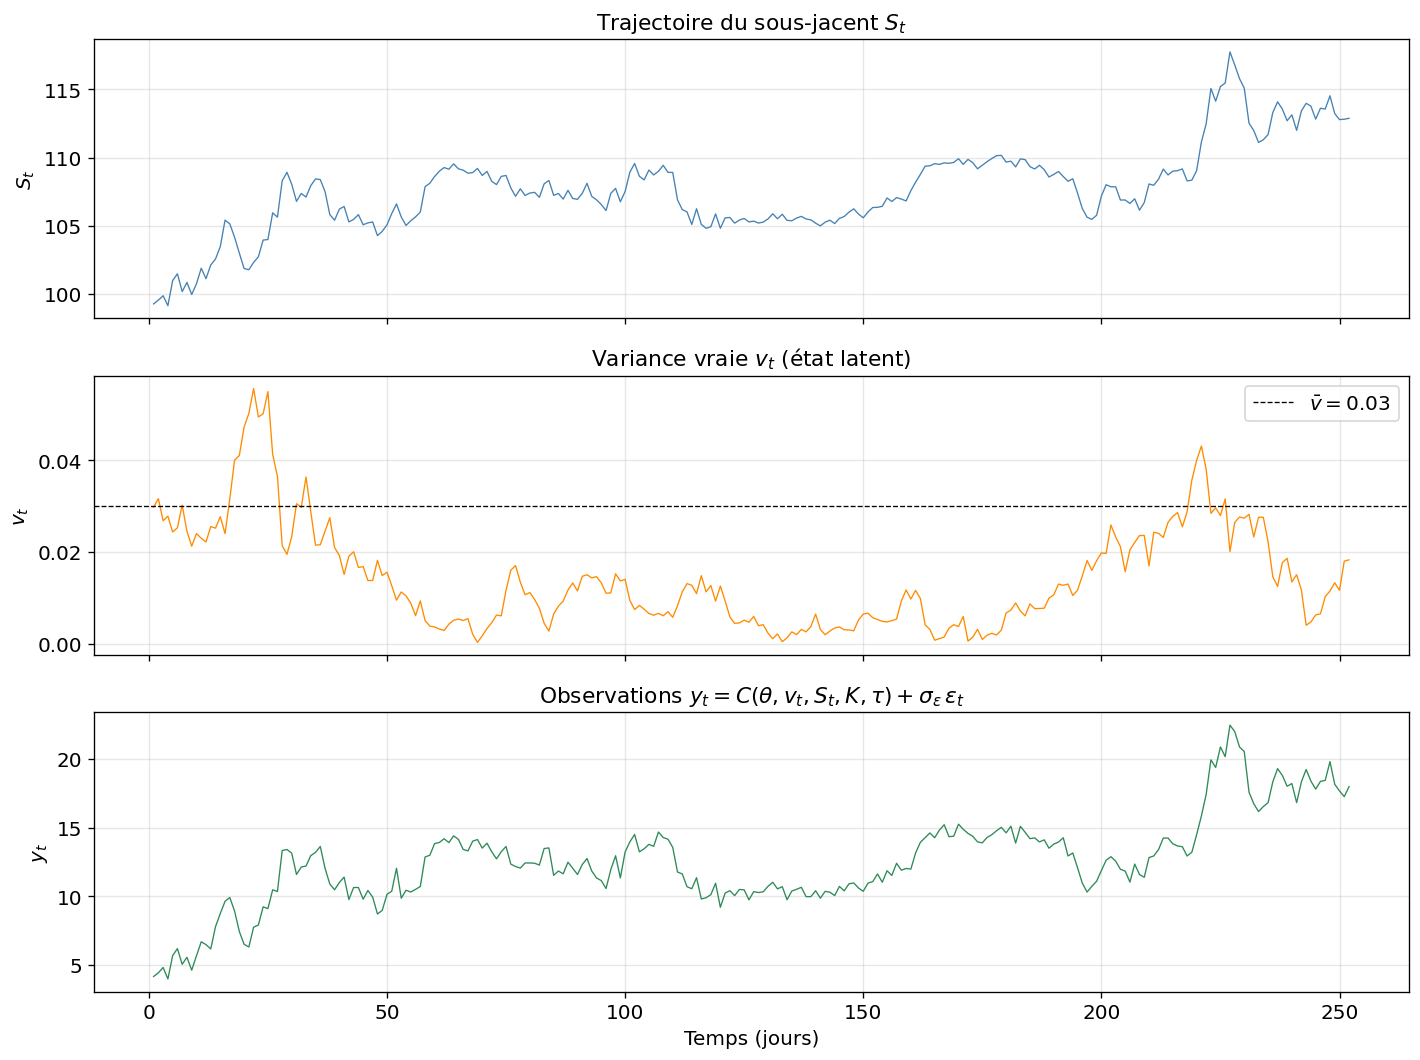

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
t_grid = np.arange(1, n + 1)

axes[0].plot(t_grid, S_true, color='steelblue', linewidth=0.8)
axes[0].set_title('Trajectoire du sous-jacent $S_t$')
axes[0].set_ylabel('$S_t$')
axes[0].grid(alpha=0.3)

axes[1].plot(t_grid, v_true, color='darkorange', linewidth=0.8)
axes[1].axhline(v_bar, color='k', linestyle='--', linewidth=0.8, label=f'$\\bar{{v}} = {v_bar}$')
axes[1].set_title('Variance vraie $v_t$ (état latent)')
axes[1].set_ylabel('$v_t$')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(t_grid, y_obs, color='seagreen', linewidth=0.8)
axes[2].set_title('Observations $y_t = C(\\theta, v_t, S_t, K, \\tau) + \\sigma_\\varepsilon\\,\\varepsilon_t$')
axes[2].set_ylabel('$y_t$')
axes[2].set_xlabel('Temps (jours)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trajectoires_reference.png', bbox_inches='tight')
plt.show()

## 5. Fonctions utilitaires du filtre particulaire

In [51]:

# ==============================
# OUTILS APF
# ==============================
def systematic_resampling(weights):
    M = len(weights)
    positions = (np.arange(M) + np.random.uniform(0, 1)) / M
    cumsum = np.cumsum(weights)
    cumsum[-1] = 1.0
    idx = np.zeros(M, dtype=int)
    i, j = 0, 0
    while i < M:
        if positions[i] < cumsum[j]:
            idx[i] = j
            i += 1
        else:
            j = min(j + 1, M - 1)
    return idx


def log_gaussian(y, mu, sigma2):
    return -0.5 * np.log(2 * np.pi * sigma2) - 0.5 * (y - mu) ** 2 / sigma2


def propagate_variance(v_prev, dt, lambda_, v_bar, eta):
    Z2 = np.random.normal(0, 1, len(v_prev))
    drift = v_prev + lambda_ * dt * (v_bar - v_prev)
    diffusion = eta * np.sqrt(np.maximum(v_prev, 0.0) * dt) * Z2
    return np.abs(drift + diffusion)


def conditional_mean_variance(v_prev, dt, lambda_, v_bar, eps=1e-8):
    drift = v_prev + lambda_ * dt * (v_bar - v_prev)
    return np.maximum(drift, eps)


def compute_call_prices_batch(S_t, v_vec, K, tau, r, lambda_, v_bar, eta, rho):
    return np.array([
        prix_call_heston_GL(S_t, float(v), K, tau, r, lambda_, v_bar, eta, rho)
        for v in v_vec
    ])



## 6. Filtre Particulaire Auxiliaire (APF) — Algorithme 1

L'APF (Pitt & Shephard, 1999) améliore le filtre Bootstrap en introduisant une étape de **pré-pondération auxiliaire** : avant de propager les particules, on calcule des poids préliminaires proportionnels à $p_\theta(y_t | \mu^i_t)$ où $\mu^i_t = \mathbb{E}_\theta[v_t | v^i_{t-1}]$. Cela concentre le nuage particulaire dans les régions de l'espace d'état compatibles avec l'observation à venir, réduisant ainsi la dégénérescence.

Les étapes pour chaque instant $t$ sont :

1. Calculer $\mu^i_t = \mathbb{E}[v_t | v^i_{t-1}]$ (approximation par drift Euler).
2. Calculer les **poids auxiliaires** : $w^{\mathrm{aux}}_i \propto \tilde{w}^i_{t-1} \cdot p_\theta(y_t | C(\mu^i_t))$.
3. **Rééchantillonner** selon $w^{\mathrm{aux}}$, obtenir les ancêtres $j_i$.
4. **Propager** : $v^i_t \sim p_\theta(v_t | v^{j_i}_{t-1})$.
5. **Corriger** les poids : $w^i_t \propto \dfrac{p_\theta(y_t | v^i_t)}{p_\theta(y_t | \mu^{j_i}_t)}$.
6. **Normaliser**, estimer $\hat{v}_t = \sum_i \tilde{w}^i_t v^i_t$.

In [52]:
# =========================
# 4) Pricing (à brancher)
# =========================
def compute_call_prices_batch(S_t, v_vec, K, tau, r, lambda_, v_bar, eta, rho):
    """
    Calcule les prix de Call pour un vecteur v_vec.
    IMPORTANT : suppose que la fonction `prix_call_heston_GL` est définie avant.
    """
    return np.array([
        prix_call_heston_GL(S_t, float(v), K, tau, r, lambda_, v_bar, eta, rho)
        for v in v_vec
    ])


# =========================
# 5) Filtre APF
# =========================

# ==============================
# FILTRE APF (maturité constante)
# ==============================
def auxiliary_particle_filter(y_obs, S_obs, n, M,
                              dt, r, lambda_, v_bar, eta, rho,
                              K, tau, sigma2_eps, verbose=True):

    shape0 = 2 * lambda_ * v_bar / (eta ** 2)
    scale0 = (eta ** 2) / (2 * lambda_)
    particles = np.random.gamma(shape=shape0, scale=scale0, size=M)
    particles = np.maximum(particles, 1e-8)
    weights = np.ones(M) / M

    v_filtered = np.zeros(n)
    y_pred = np.zeros(n)

    for t in range(n):
        if verbose and t % 50 == 0:
            print(f"  APF — pas t = {t+1}/{n}")

        S_t = S_obs[t]
        y_t = y_obs[t]

        mu_t = conditional_mean_variance(particles, dt, lambda_, v_bar)

        call_mu = compute_call_prices_batch(S_t, mu_t, K, tau, r, lambda_, v_bar, eta, rho)

        log_w_aux = np.log(weights + 1e-300) + log_gaussian(y_t, call_mu, sigma2_eps)
        log_w_aux -= np.max(log_w_aux)
        w_aux = np.exp(log_w_aux)
        w_aux /= np.sum(w_aux)

        idx = systematic_resampling(w_aux)
        particles_anc = particles[idx]
        call_mu_anc = call_mu[idx]

        particles_new = propagate_variance(particles_anc, dt, lambda_, v_bar, eta)

        call_new = compute_call_prices_batch(S_t, particles_new, K, tau, r, lambda_, v_bar, eta, rho)

        log_w_num = log_gaussian(y_t, call_new, sigma2_eps)
        log_w_den = log_gaussian(y_t, call_mu_anc, sigma2_eps)
        log_w_new = log_w_num - log_w_den
        log_w_new -= np.max(log_w_new)
        weights_new = np.exp(log_w_new)
        weights_new /= np.sum(weights_new)

        particles, weights = particles_new, weights_new

        v_filtered[t] = np.dot(weights, particles)
        y_pred[t] = np.dot(weights, call_new)

    return v_filtered, y_pred


In [53]:
M = 300  # Nombre de particules (compromis précision / temps de calcul)

print(f"Lancement du filtre APF avec M = {M} particules...")
t0 = time.time()
v_apf, y_pred_apf = auxiliary_particle_filter(
    y_obs, S_true, n, M, dt, r, lambda_, v_bar, eta, rho,
    K, tau, sigma2_eps, verbose=True
)
t1 = time.time()
print(f"APF terminé en {t1-t0:.1f}s.")

Lancement du filtre APF avec M = 300 particules...
  APF — pas t = 1/252
  APF — pas t = 51/252
  APF — pas t = 101/252
  APF — pas t = 151/252
  APF — pas t = 201/252
  APF — pas t = 251/252
APF terminé en 51910.7s.


## 7. Filtre Bootstrap (BPF)

Le filtre Bootstrap constitue un cas particulier dans lequel il n'y a pas d'étape de pré-pondération : les particules sont propagées depuis la prior de transition, puis pondérées directement par la vraisemblance de l'observation courante. Cette stratégie peut souffrir d'une dégénérescence particulaire plus importante lorsque le bruit de mesure est faible relativement au bruit de dynamique.

In [ ]:
def bootstrap_particle_filter(y_obs, S_obs, n, M,
                              dt, r, lambda_, v_bar, eta, rho,
                              K, tau, sigma2_eps,
                              ess_ratio=0.5,  # seuil ESS/M (mettre 1.0 pour resampler à chaque pas)
                              verbose=True):
    """
    Filtre particulaire Bootstrap (SIR), conforme aux attendus classiques :

    - Etat latent : v_t
    - Observation : y_t = C(v_t, S_t, K, tau) + bruit, donc
                   p(y_t | v_t) = N(C(...), sigma2_eps)
    - Proposition : q(v_t | v_{t-1}) = p(v_t | v_{t-1}) (transition du modèle)
    - Mise à jour : w_t^i ∝ w_{t-1}^i * p(y_t | v_t^i)
    - Resampling : selon ESS (ou à chaque pas si ess_ratio=1.0)

    Prérequis (déjà dans ton code) :
      - propagate_variance(...)
      - log_gaussian(...)
      - systematic_resampling(...)
      - compute_call_prices_batch(...) qui appelle prix_call_heston_GL(...)
    """

    # --- Initialisation (t=0) : prior sur v0 (Gamma, approx stationnaire CIR) ---
    shape0 = 2 * lambda_ * v_bar / (eta**2)
    scale0 = (eta**2) / (2 * lambda_)
    particles = np.random.gamma(shape=shape0, scale=scale0, size=M)
    particles = np.maximum(particles, 1e-8)
    weights = np.ones(M) / M  # poids uniformes

    v_filtered = np.zeros(n)
    y_pred     = np.zeros(n)
    ess_hist   = np.zeros(n)

    for t in range(n):
        if verbose and t % 50 == 0:
            print(f"  BPF — pas t = {t+1}/{n}")

        S_t = S_obs[t]
        y_t = y_obs[t]

        # --- (1) Propagation : v_t^i ~ p(v_t | v_{t-1}^i) ---
        particles = propagate_variance(particles, dt, lambda_, v_bar, eta)

        # --- (2) Poids : w_t^i ∝ w_{t-1}^i * p(y_t | v_t^i) ---
        call_t = compute_call_prices_batch(S_t, particles, K, tau,
                                           r, lambda_, v_bar, eta, rho)

        logw = np.log(weights + 1e-300) + log_gaussian(y_t, call_t, sigma2_eps)
        logw -= np.max(logw)  # stabilité numérique
        weights = np.exp(logw)
        weights /= np.sum(weights)

        # --- (3) Estimations filtrées (avec poids normalisés, AVANT resampling) ---
        v_filtered[t] = np.dot(weights, particles)
        y_pred[t]     = np.dot(weights, call_t)

        # --- (4) ESS + resampling (SIR) ---
        ess = 1.0 / np.sum(weights**2)
        ess_hist[t] = ess

        if ess < ess_ratio * M:
            idx = systematic_resampling(weights)
            particles = particles[idx]
            weights = np.ones(M) / M  # après resampling, poids uniformes

    return v_filtered, y_pred, ess_hist

In [ ]:
M = 300
print(f"Lancement du filtre Bootstrap (BPF) avec M = {M} particules :")
t0 = time.time()
v_bpf, y_pred_bpf, ess_bpf = bootstrap_particle_filter(
    y_obs, S_true, n, M, dt, r, lambda_, v_bar, eta, rho,
    K, tau, sigma2_eps, ess_ratio=0.5, verbose=True
)
t1 = time.time()
print(f"BPF terminé en {t1-t0:.1f}s.")
print(f"ESS min = {ess_bpf.min():.1f} / {M}")

Lancement du filtre Bootstrap (BPF) avec M = 300 particules :
  BPF — pas t = 1/252
  BPF — pas t = 51/252


## 8. Comparaison et évaluation des deux filtres

### 8.1 Critère MSE

On calcule la MSE entre les observations $(y_t)$ et les prédictions $\hat{y}_t$ de chaque filtre :

$$
\mathrm{MSE} = \frac{1}{n} \sum_{t=1}^{n} (y_t - \hat{y}_t)^2
$$

ainsi que la MSE sur la variance latente (par rapport à la trajectoire de référence simulée) :

$$
\mathrm{MSE}_v = \frac{1}{n} \sum_{t=1}^{n} (v_t - \hat{v}_t)^2
$$

In [ ]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


mse_apf   = mse(y_obs, y_pred_apf)
mse_bpf   = mse(y_obs, y_pred_bpf)
mse_v_apf = mse(v_true, v_apf)
mse_v_bpf = mse(v_true, v_bpf)

print("=" * 58)
print(f"  {'Critère':<32} {'APF':>10} {'BPF':>10}")
print("=" * 58)
print(f"  {'MSE(y_obs, y_pred)':<32} {mse_apf:>10.6f} {mse_bpf:>10.6f}")
print(f"  {'MSE(v_true, v_filtered)':<32} {mse_v_apf:>10.6f} {mse_v_bpf:>10.6f}")
print("=" * 58)
reduction = (mse_bpf - mse_apf) / mse_bpf * 100
print(f"  Réduction MSE(y) APF vs BPF : {reduction:.2f} %")

  Critère                                 APF        BPF
  MSE(y_obs, y_pred)                 0.091024   0.091024
  MSE(v_true, v_filtered)            0.000398   0.000365
  Réduction MSE(y) APF vs BPF : 0.00 %


### 8.2 Visualisation des trajectoires filtrées

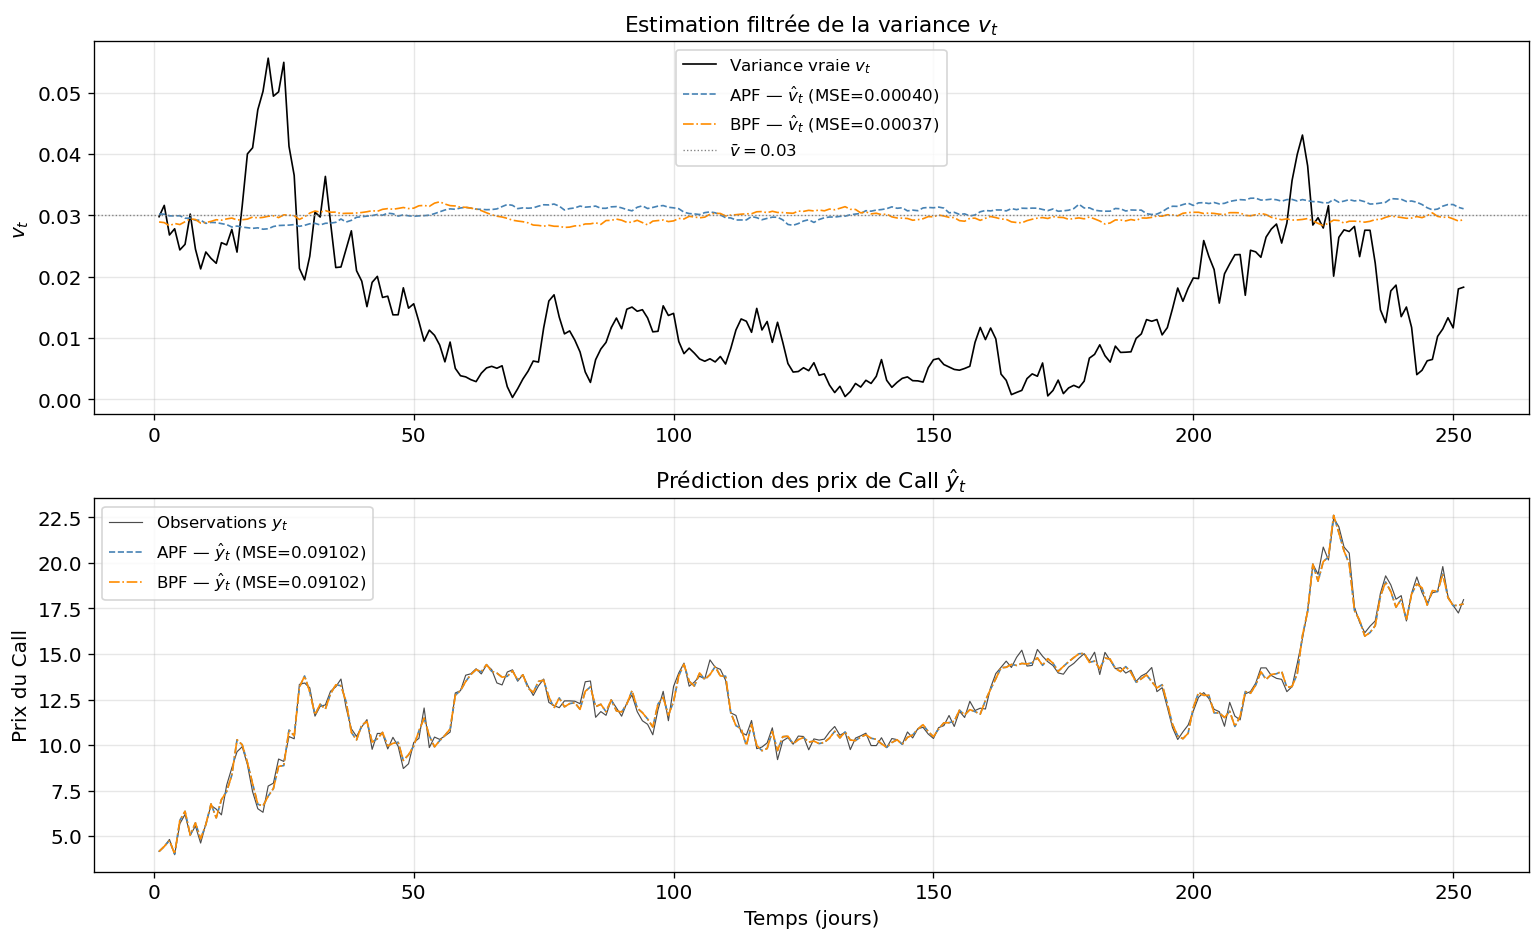

In [ ]:
t_grid = np.arange(1, n + 1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

ax = axes[0]
ax.plot(t_grid, v_true, color='black',      lw=1.0,  label='Variance vraie $v_t$')
ax.plot(t_grid, v_apf,  color='steelblue',  lw=1.0,  linestyle='--',
        label=f'APF — $\\hat{{v}}_t$ (MSE={mse_v_apf:.5f})')
ax.plot(t_grid, v_bpf,  color='darkorange', lw=1.0,  linestyle='-.',
        label=f'BPF — $\\hat{{v}}_t$ (MSE={mse_v_bpf:.5f})')
ax.axhline(v_bar, color='gray', lw=0.8, linestyle=':', label=f'$\\bar{{v}}={v_bar}$')
ax.set_title('Estimation filtrée de la variance $v_t$')
ax.set_ylabel('$v_t$')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_grid, y_obs,      color='black',      lw=0.7, alpha=0.7, label='Observations $y_t$')
ax.plot(t_grid, y_pred_apf, color='steelblue',  lw=1.0, linestyle='--',
        label=f'APF — $\\hat{{y}}_t$ (MSE={mse_apf:.5f})')
ax.plot(t_grid, y_pred_bpf, color='darkorange', lw=1.0, linestyle='-.',
        label=f'BPF — $\\hat{{y}}_t$ (MSE={mse_bpf:.5f})')
ax.set_title('Prédiction des prix de Call $\\hat{y}_t$')
ax.set_ylabel('Prix du Call')
ax.set_xlabel('Temps (jours)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_filtres.png', bbox_inches='tight')
plt.show()

### 8.3 Analyse des résidus

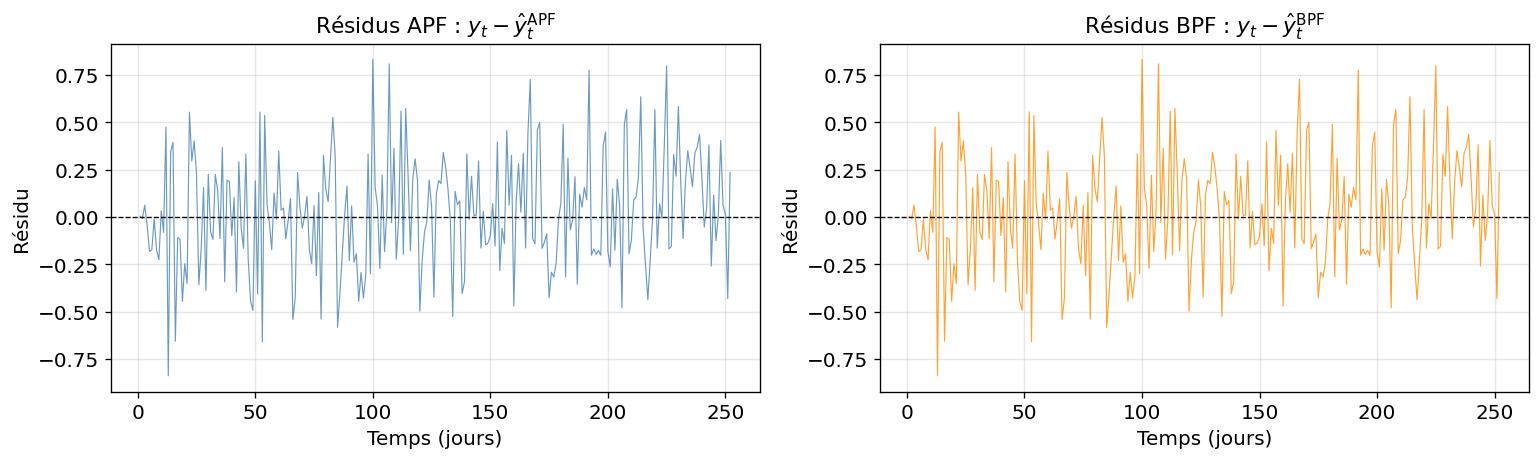

Résidus APF — moyenne : 0.024755, écart-type : 0.300685
Résidus BPF — moyenne : 0.024755, écart-type : 0.300685


In [ ]:
resid_apf = y_obs - y_pred_apf
resid_bpf = y_obs - y_pred_bpf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_grid, resid_apf, color='steelblue', lw=0.7, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8, linestyle='--')
axes[0].set_title('Résidus APF : $y_t - \\hat{y}_t^{\\mathrm{APF}}$')
axes[0].set_xlabel('Temps (jours)')
axes[0].set_ylabel('Résidu')
axes[0].grid(alpha=0.3)

axes[1].plot(t_grid, resid_bpf, color='darkorange', lw=0.7, alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
axes[1].set_title('Résidus BPF : $y_t - \\hat{y}_t^{\\mathrm{BPF}}$')
axes[1].set_xlabel('Temps (jours)')
axes[1].set_ylabel('Résidu')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residus_filtres.png', bbox_inches='tight')
plt.show()

print(f"Résidus APF — moyenne : {resid_apf.mean():.6f}, écart-type : {resid_apf.std():.6f}")
print(f"Résidus BPF — moyenne : {resid_bpf.mean():.6f}, écart-type : {resid_bpf.std():.6f}")

## 9. Sensibilité au nombre de particules

On étudie l'influence de $M$ sur la MSE des deux filtres. Pour chaque valeur de $M$, on ré-exécute les deux filtres sur les mêmes données $(y_t, S_t)$.

In [ ]:
M_values = [50, 100, 200, 300, 500]
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # 10 répétitions

mse_apf_mean, mse_apf_std = [], []
mse_bpf_mean, mse_bpf_std = [], []

for M_val in M_values:
    mse_apf_runs = []
    mse_bpf_runs = []

    for sd in seeds:
        np.random.seed(sd)
        _, yp_apf = auxiliary_particle_filter(
            y_obs, S_true, n, M_val, dt, r, lambda_, v_bar, eta, rho,
            K, tau, sigma2_eps, verbose=False
        )
        np.random.seed(sd)
        _, yp_bpf, _ = bootstrap_particle_filter(
        y_obs, S_true, n, M_val, dt, r, lambda_, v_bar, eta, rho,
        K, tau, sigma2_eps, verbose=False)
        yp_bpf = bootstrap_particle_filter(
        y_obs, S_true, n, M_val, dt, r, lambda_, v_bar, eta, rho,
        K, tau, sigma2_eps, verbose=False
        )

        mse_apf_runs.append(mse(y_obs, yp_apf))
        mse_bpf_runs.append(mse(y_obs, yp_bpf))

    mse_apf_mean.append(np.mean(mse_apf_runs))
    mse_apf_std.append(np.std(mse_apf_runs, ddof=1))
    mse_bpf_mean.append(np.mean(mse_bpf_runs))
    mse_bpf_std.append(np.std(mse_bpf_runs, ddof=1))

print("\nSensibilité au nombre de particules (moyenne ± std sur seeds) :")
print(f"{'M':<8} {'APF mean':>12} {'APF std':>12} {'BPF mean':>12} {'BPF std':>12}")
for M_val, ma, sa, mb, sb in zip(M_values, mse_apf_mean, mse_apf_std, mse_bpf_mean, mse_bpf_std):
    print(f"{M_val:<8} {ma:>12.6f} {sa:>12.6f} {mb:>12.6f} {sb:>12.6f}")

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(M_values, mse_apf_list, 'o-', color='steelblue',  lw=1.5, label='APF')
ax.plot(M_values, mse_bpf_list, 's-', color='darkorange', lw=1.5, label='BPF')
ax.set_xlabel('Nombre de particules $M$')
ax.set_ylabel('MSE$(y_t,\\,\\hat{y}_t)$')
ax.set_title('Sensibilité de la MSE au nombre de particules')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sensibilite_M.png', bbox_inches='tight')
plt.show()

## 10. Bilan et interprétation

In [ ]:
print("BILAN DE LA CALIBRATION")
print("=" * 65)
print(f"Modèle         : Heston discrétisé, schéma d'Euler modifié")
print(f"Paramètres     : lambda={lambda_}, eta={eta}, v_bar={v_bar}, rho={rho}")
print(f"Observations   : n={n}, K={K}, tau={tau} (constant), r={r}")
print(f"Bruit de mesure: sigma_eps^2 = {sigma2_eps}")
print(f"Particules     : M = {M}")
print(f"Quadrature     : Gauss-Laguerre, N_quad = {N_QUAD} noeuds")
print()
print(f"{'Filtre':<12} {'MSE(y)':<16} {'MSE(v)':<16}")
print("-" * 44)
print(f"{'APF':<12} {mse_apf:<16.6f} {mse_v_apf:<16.6f}")
print(f"{'BPF':<12} {mse_bpf:<16.6f} {mse_v_bpf:<16.6f}")
print()
print("Corrections apportées par rapport à une version naïve :")
print("""
1. Maturité tau constante dans la simulation et le filtre (Call rolling),
   conformément à l'interprétation directe de l'énoncé.

2. Fonction caractéristique stabilisée (Little Heston Trap) pour éviter
   les discontinuités de branche du logarithme complexe, sources de prix
   aberrants pour certaines particules.

3. Espérance conditionnelle mu_t^i définie comme le drift Euler sans valeur
   absolue, avec plancher epsilon > 0 uniquement pour le pricing. La valeur
   absolue biaiserait l'étape de pré-pondération auxiliaire.

4. Propagation nettoyée : la corrélation rho et l'innovation Z1 sont exclus
   de la fonction de propagation de v_t, puisque S_t est observé et ne
   nécessite pas de simulation jointe.

5. Quadrature de Gauss-Laguerre pré-calculée (N=64 noeuds) en lieu et place
   de scipy.integrate.quad, réduisant le coût de pricing d'un facteur > 100.
""")

---

## Annexe : Références

- **Albrecher, H., Mayer, P., Schachermayer, W., & Teichmann, J. (2007)**. The little Heston trap. *Wilmott Magazine*, 83–92.

- **Heston, S. L. (1993)**. A closed-form solution for options with stochastic volatility with applications to bond and currency options. *The Review of Financial Studies*, 6(2), 327–343.

- **Cox, J. C., Ingersoll, J. E., & Ross, S. A. (1985)**. A Theory of the Term Structure of Interest Rates. *Econometrica*, 53(2), 385–407.

- **Pitt, M. K., & Shephard, N. (1999)**. Filtering via simulation: Auxiliary particle filters. *Journal of the American Statistical Association*, 94(446), 590–599.

- **Doucet, A., Freitas, N. de, & Gordon, N. (Eds.) (2001)**. *Sequential Monte Carlo Methods in Practice*. Springer.